In [1]:
import os
import pandas as pd

folder_path = 'dados_csv'
all_dfs = []

# mapping of long → short names (only applied to the specific file)
rename_map = {
    'atm_wnd_spd_10m (vel de vento)': 'atm_wnd_spd_10m',
    'wav_hs (altura de onda)': 'wav_hs',
    'sw_cur_spd (vel. Corrente)': 'sw_cur_spd'
}

target_filename = "era5_wnd_wav_and_cmems_re_bra_cur2d_FZA-M-59 - PUC.csv"

for filename in os.listdir(folder_path):
    if filename == "processed_metocean_current_data.csv":
        #output dataframe, skip processing
        continue

    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        temp_df = pd.read_csv(file_path)

        # Apply renaming only to the target file
        if filename == target_filename:
            temp_df = temp_df.rename(columns=rename_map)

            # print ammount of columns
        print(f"Total columns: {len(temp_df.columns)}")

        all_dfs.append(temp_df)

df = pd.concat(all_dfs, ignore_index=True)
print(len(df.columns))

Total columns: 40
Total columns: 40
Total columns: 40
Total columns: 40
Total columns: 40
Total columns: 40
40


In [2]:
# print ammount of column
print(f"Total columns: {len(df.columns)}")

Total columns: 40


In [3]:
# drop lines with any NaN values
df = df.dropna()

In [4]:

mydf = df
# Assuming your dataframe is already loaded as mydf
corr_matrix = mydf.corr(numeric_only=True)

print("Correlation matrix:")
print(corr_matrix) 


Correlation matrix:
                 latitude  longitude  atm_wnd_spd_10m  atm_wnd_dir_10m  \
latitude         1.000000  -0.594086         0.021469         0.006801   
longitude       -0.594086   1.000000        -0.013862        -0.004579   
atm_wnd_spd_10m  0.021469  -0.013862         1.000000        -0.483106   
atm_wnd_dir_10m  0.006801  -0.004579        -0.483106         1.000000   
wav_hs           0.020242   0.005722         0.743003        -0.487711   
wav_hmax         0.020389   0.005684         0.761324        -0.493132   
wav_tp          -0.005015   0.014394         0.024392        -0.107585   
wav_tmm10        0.001360   0.017467        -0.105558        -0.087368   
wav_tm01         0.004401   0.022268        -0.245301        -0.019838   
wav_tm02         0.007156   0.025059        -0.299006         0.000410   
wav_hmaxt        0.003110   0.020720        -0.232359        -0.019816   
wav_dm           0.011794  -0.000787        -0.308400         0.505136   
wav_ww_hs        0

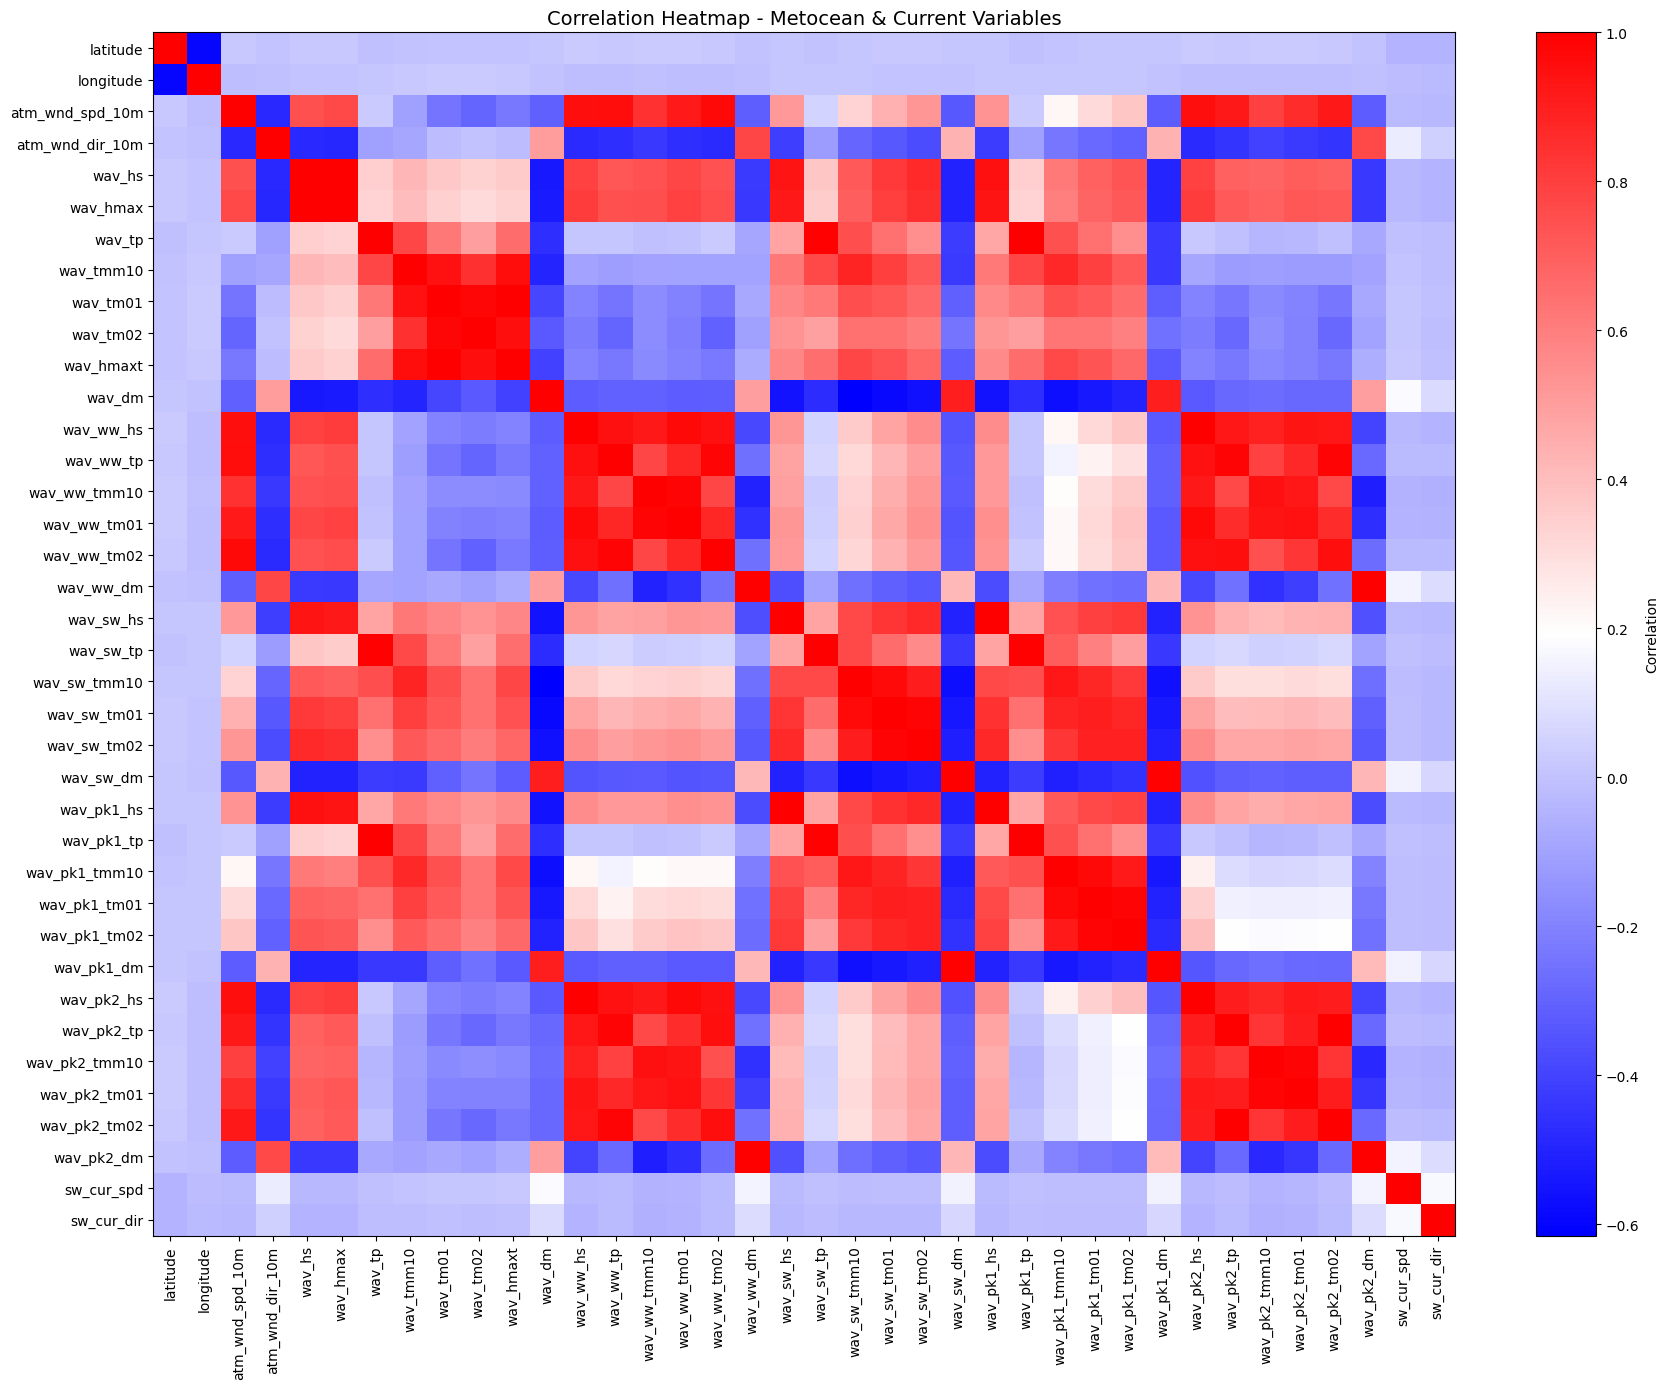

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 14))
plt.imshow(corr_matrix, aspect='auto', cmap='bwr')
# red and blue colors
plt.colorbar(label="Correlation", cmap='bwr')

plt.title("Correlation Heatmap - Metocean & Current Variables", fontsize=14)

# Add labels
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.tight_layout()
plt.show()


# 1. componentes vetoriais (u/v) para entrada normalizada

0=360 e 1 é proximo de 359

In [6]:
import numpy as np
import pandas as pd

df = mydf.copy()

# Helper function: convert direction (deg) + magnitude into u/v
def dir_to_uv(direction_deg, magnitude):
    theta = np.deg2rad(direction_deg)
    
    # Meteorological: direction FROM
    u = -magnitude * np.sin(theta)
    v = -magnitude * np.cos(theta)
    return u, v

# Map directions to their magnitudes
magnitude_map = {
    "atm_wnd_dir_10m": "atm_wnd_spd_10m",
    "wav_dm": "wav_hs",
    "wav_ww_dm": "wav_ww_hs",
    "wav_sw_dm": "wav_sw_hs",
    "wav_pk1_dm": "wav_pk1_hs",
    "wav_pk2_dm": "wav_pk2_hs",
    "sw_cur_dir": "sw_cur_spd"
}

# Automatically convert each direction column from magnitude_map
for dir_col, mag_col in magnitude_map.items():
    if dir_col not in df.columns:
        print(f"⚠️ Direction column {dir_col} not found in data, skipping...")
        continue
    
    if mag_col not in df.columns:
        print(f"⚠️ Magnitude column {mag_col} not found in data, skipping...")
        continue
    
    u_component, v_component = dir_to_uv(df[dir_col], df[mag_col])
    
    df[f"{dir_col}_u"] = u_component
    df[f"{dir_col}_v"] = v_component

print("✅ Finished generating u/v components.")

✅ Finished generating u/v components.


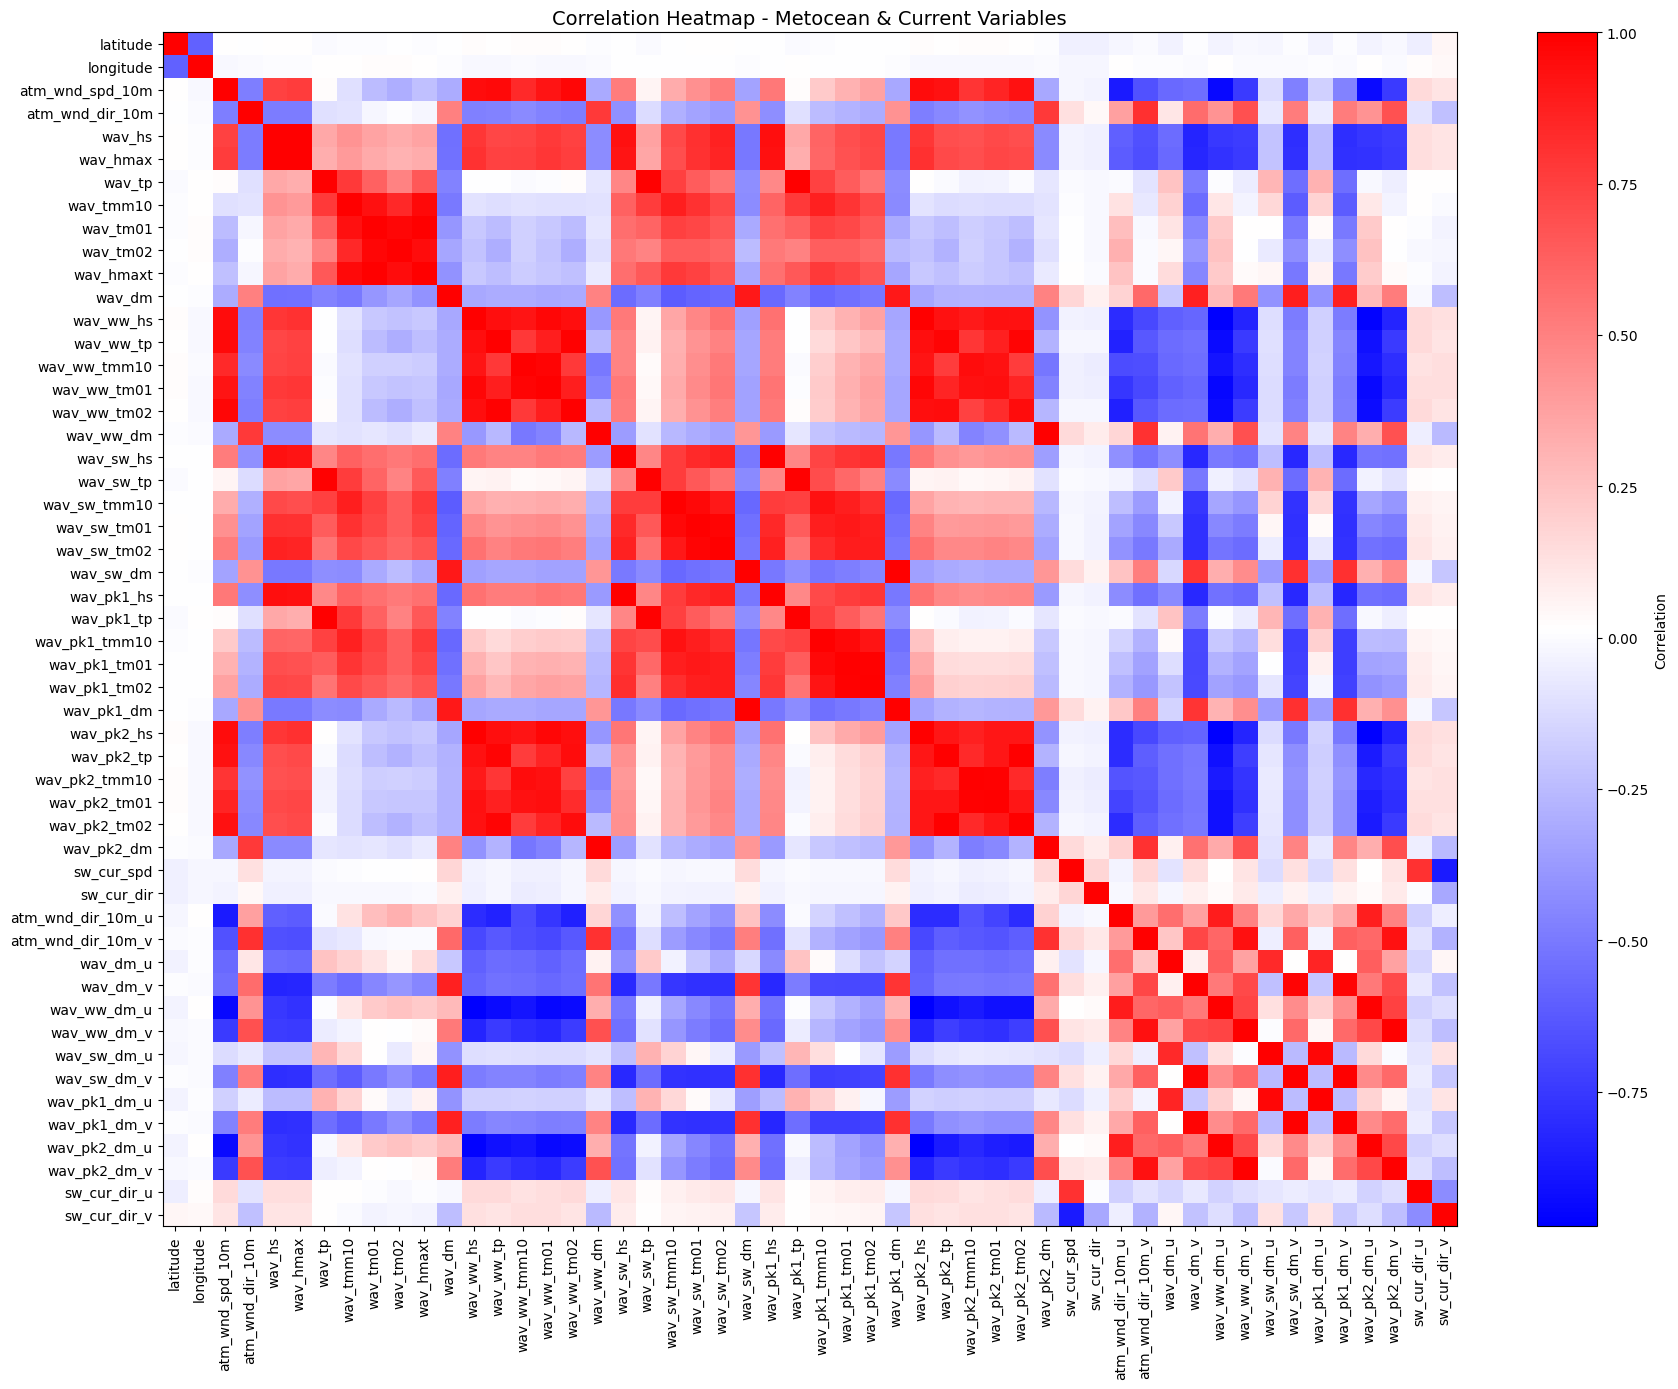

In [7]:

mydf = df
# Assuming your dataframe is already loaded as mydf
corr_matrix = mydf.corr(numeric_only=True)



import matplotlib.pyplot as plt

plt.figure(figsize=(18, 14))
plt.imshow(corr_matrix, aspect='auto', cmap='bwr')
# red and blue colors
plt.colorbar(label="Correlation", cmap='bwr')

plt.title("Correlation Heatmap - Metocean & Current Variables", fontsize=14)

# Add labels
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.tight_layout()
plt.show()


## 3. Criação de Features de Domínio Marítimo

A modelagem de correntes superficiais em ambientes offshore exige
variáveis que representem os principais mecanismos físicos que governam
a dinâmica da camada superficial do oceano. A literatura demonstra que
tanto o **forçamento pelo vento (Ekman + correntes impulsionadas pelo
vento)** quanto os **efeitos das ondas (Stokes drift + interações
onda--corrente)** influenciam diretamente a velocidade e a direção das
correntes superficiais. A seguir justificamos cada conjunto de variáveis
com base em evidências científicas.

------------------------------------------------------------------------

### **A. Wind Forcing (Ekman + Wind-Driven Currents)**

**Variáveis:** - `atm_wnd_spd_10m`\
- `atm_wnd_dir_10m_u/v`

O vento é o principal mecanismo que impulsiona a circulação superficial
na camada de Ekman. A intensidade e a direção do vento determinam o
estresse de superfície e, portanto, o transporte horizontal da água.
Estudos demonstram que o alinhamento entre o estresse do vento e a
corrente superficial é crítico para prever a velocidade das correntes,
especialmente em regiões tropicais e equatoriais. Também há evidências
de que o estado do mar modula a fração do estresse do vento que
realmente é transferida para o oceano (Wu et al., 2008).

Além disso, a interação entre vento e ondas modifica o perfil de
velocidade da camada superficial, significando que modelos baseados
apenas no vento ignoram parte relevante da dinâmica observada (Polton et
al., 2005).

**Referências-chave:** Polton et al. (2005); Wu et al. (2008)

------------------------------------------------------------------------

### **B. Wave-Driven Currents (Stokes Drift + Interações Onda--Corrente)**

**Variáveis:** - `wav_hs`, `wav_tp`, `wav_tmm10`, `wav_dm_u/v`\
- `wav_sw_hs`, `wav_sw_tp`\
- Partições espectrais: `wav_pk1_*`, `wav_pk2_*`

O **Stokes drift** representa o transporte líquido induzido pelas ondas
e é fortemente correlacionado com energia de ondas de vento e swell.
Estudos recentes mostram que incluir Stokes drift em modelos de predição
melhora significativamente o desempenho --- com reduções de 30% a 40% no
erro de trajetória em sistemas de deriva superficial (Tamtare et al.,
2021).

Em regiões dominadas por swell, o Stokes drift pode ser ainda mais
influente, justificando as variáveis de swell (`wav_sw_*`). Em bacias
com mares multidirecionais, as partições espectrais (`pk1`, `pk2`)
capturam melhor o espectro direcional, o que melhora a representação
física do transporte superficial.

Modelos acoplados (onda--corrente) também mostram que correntes
Eulerianas induzidas por ondas contribuem significativamente para o
transporte de massa na superfície, reforçando a necessidade de incluir
variáveis de ondas (Rühs et al., 2025; Perrie et al., 2003; Causio et
al., 2021).

**👉 Engineering trick:**\
Usar **proxies de energia de ondas**, como `Hs^2 * Tp`, fornece um
resumo eficiente do estado energético do mar para modelos de ML.

**Referências-chave:** Tamtare et al. (2021); Rühs et al. (2025); Perrie
et al. (2003); Causio et al. (2021)

------------------------------------------------------------------------

### **Referências (APA)**

-   Causio, S., et al. (2021). *A modelling approach for the assessment
    of wave--current interactions in a wavy ocean*. Journal of Marine
    Science and Engineering, 9(8), 893.\
-   Perrie, W., et al. (2003). *The impact of waves on surface
    currents*. Journal of Physical Oceanography, 33(10), 2126--2140.\
-   Polton, J. A., Lewis, D. M., & Belcher, S. E. (2005). *The role of
    wave-induced Coriolis--Stokes forcing on the wind-driven mixed
    layer*.\
-   Rühs, S., et al. (2025). *Non-negligible impact of Stokes drift and
    wave-driven Eulerian currents in Lagrangian surface drift
    simulations*. Ocean Science, 21, 217--234.\
-   Tamtare, D., Dumont, D., & Chavanne, C. (2021). *The Stokes drift in
    ocean surface drift prediction*.\
-   Wu, F., et al. (2008). *Wave energy input into the Ekman layer*.
    Science in China Series D: Earth Sciences, 51(6), 875--885.

In [8]:
import numpy as np

df["wave_energy"] = df["wav_hs"]**2
df["swell_energy"] = df["wav_sw_hs"]**2
df["windwave_energy"] = df["wav_ww_hs"]**2

# Direction alignment:
df["wind_current_alignment"] = (
    df["atm_wnd_dir_10m_u"] * df["sw_cur_dir_u"] +
    df["atm_wnd_dir_10m_v"] * df["sw_cur_dir_v"]
)


### **Redução de dimensionalidade (PCA)**

Dado que os clusters representam modos físicos coerentes, técnicas como
**PCA** podem ser usadas para:

-   reduzir dimensionalidade dos dados,\
-   condensar variáveis altamente correlacionadas em poucos
    componentes,\
-   e preservar interpretações físicas (e.g., "modo swell", "modo ondas
    de vento", "modo mares cruzados").

Isso reduz redundância e melhora o desempenho de modelos de machine
learning preservando o significado geofísico.

In [9]:
features_for_pca = [
    col for col in df.columns
    if any(key in col for key in ["u", "v", "_energy", "tm", "tp", "hs"])
    and col != "sw_cur_spd"
]
print(features_for_pca)


['latitude', 'longitude', 'atm_wnd_spd_10m', 'atm_wnd_dir_10m', 'wav_hs', 'wav_hmax', 'wav_tp', 'wav_tmm10', 'wav_tm01', 'wav_tm02', 'wav_hmaxt', 'wav_dm', 'wav_ww_hs', 'wav_ww_tp', 'wav_ww_tmm10', 'wav_ww_tm01', 'wav_ww_tm02', 'wav_ww_dm', 'wav_sw_hs', 'wav_sw_tp', 'wav_sw_tmm10', 'wav_sw_tm01', 'wav_sw_tm02', 'wav_sw_dm', 'wav_pk1_hs', 'wav_pk1_tp', 'wav_pk1_tmm10', 'wav_pk1_tm01', 'wav_pk1_tm02', 'wav_pk1_dm', 'wav_pk2_hs', 'wav_pk2_tp', 'wav_pk2_tmm10', 'wav_pk2_tm01', 'wav_pk2_tm02', 'wav_pk2_dm', 'sw_cur_dir', 'atm_wnd_dir_10m_u', 'atm_wnd_dir_10m_v', 'wav_dm_u', 'wav_dm_v', 'wav_ww_dm_u', 'wav_ww_dm_v', 'wav_sw_dm_u', 'wav_sw_dm_v', 'wav_pk1_dm_u', 'wav_pk1_dm_v', 'wav_pk2_dm_u', 'wav_pk2_dm_v', 'sw_cur_dir_u', 'sw_cur_dir_v', 'wave_energy', 'swell_energy', 'windwave_energy', 'wind_current_alignment']


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features_for_pca])


In [11]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)


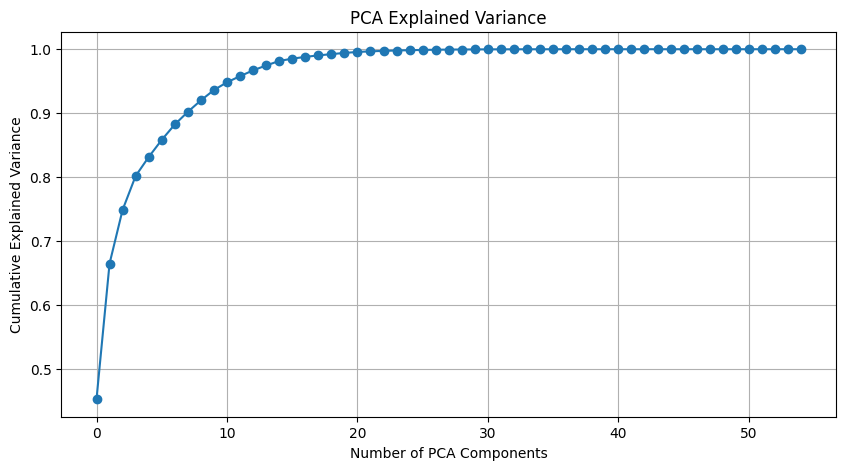

In [12]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()


In [13]:
n_components = 8  # escolhido baseado no plot
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

In [14]:
for i in range(X_pca.shape[1]):
    df[f"PCA_{i+1}"] = X_pca[:, i]

In [15]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PCA_{i+1}" for i in range(pca.n_components_)],
    index=features_for_pca
)

print(loadings)


                           PCA_1     PCA_2     PCA_3     PCA_4     PCA_5  \
latitude                0.003780 -0.005115 -0.011194  0.012133  0.642953   
longitude               0.000055  0.006614 -0.000515  0.006864 -0.606881   
atm_wnd_spd_10m         0.163335 -0.141931 -0.028242 -0.109716  0.010870   
atm_wnd_dir_10m        -0.119606  0.024279 -0.204882 -0.176785  0.081497   
wav_hs                  0.192075  0.015040 -0.096677  0.059540  0.001354   
wav_hmax                0.192740  0.006920 -0.093220  0.054841  0.001057   
wav_tp                  0.074343  0.208349 -0.006226 -0.204055  0.020619   
wav_tmm10               0.076306  0.258228 -0.072022 -0.020301  0.009517   
wav_tm01                0.054823  0.255853 -0.108471  0.106884  0.002993   
wav_tm02                0.044454  0.237130 -0.115025  0.186464 -0.001822   
wav_hmaxt               0.055677  0.260446 -0.105123  0.074948  0.004883   
wav_dm                 -0.128660 -0.116956 -0.229010  0.044605  0.022778   
wav_ww_hs   

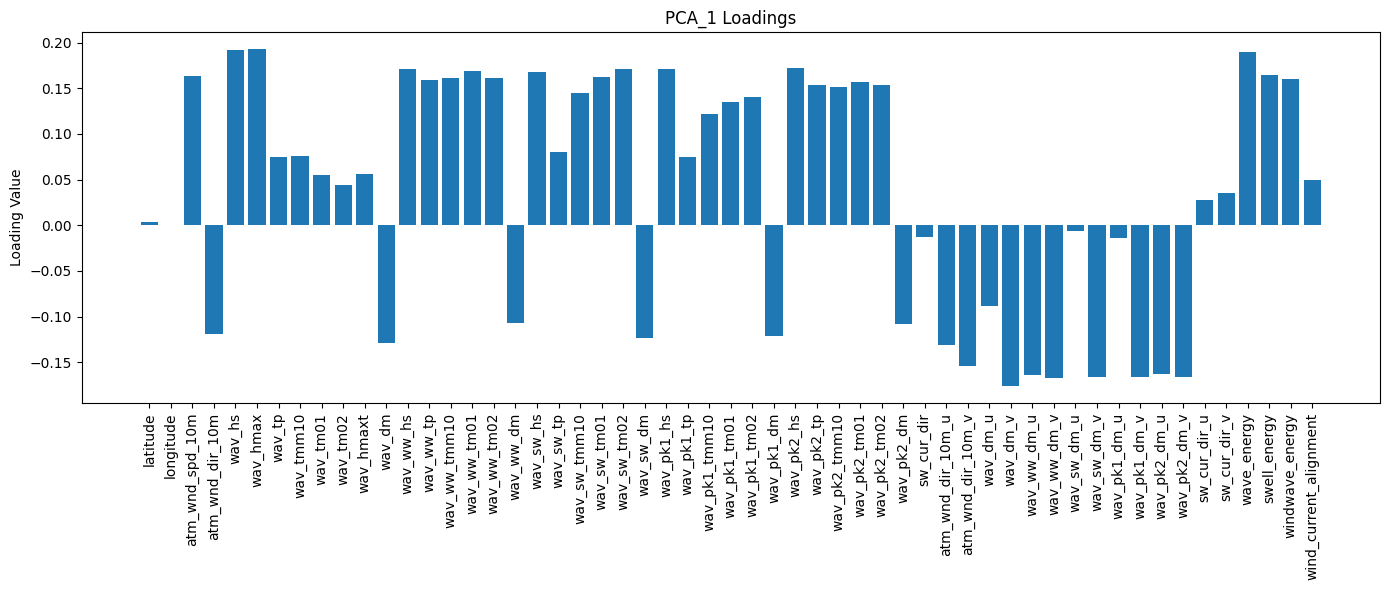

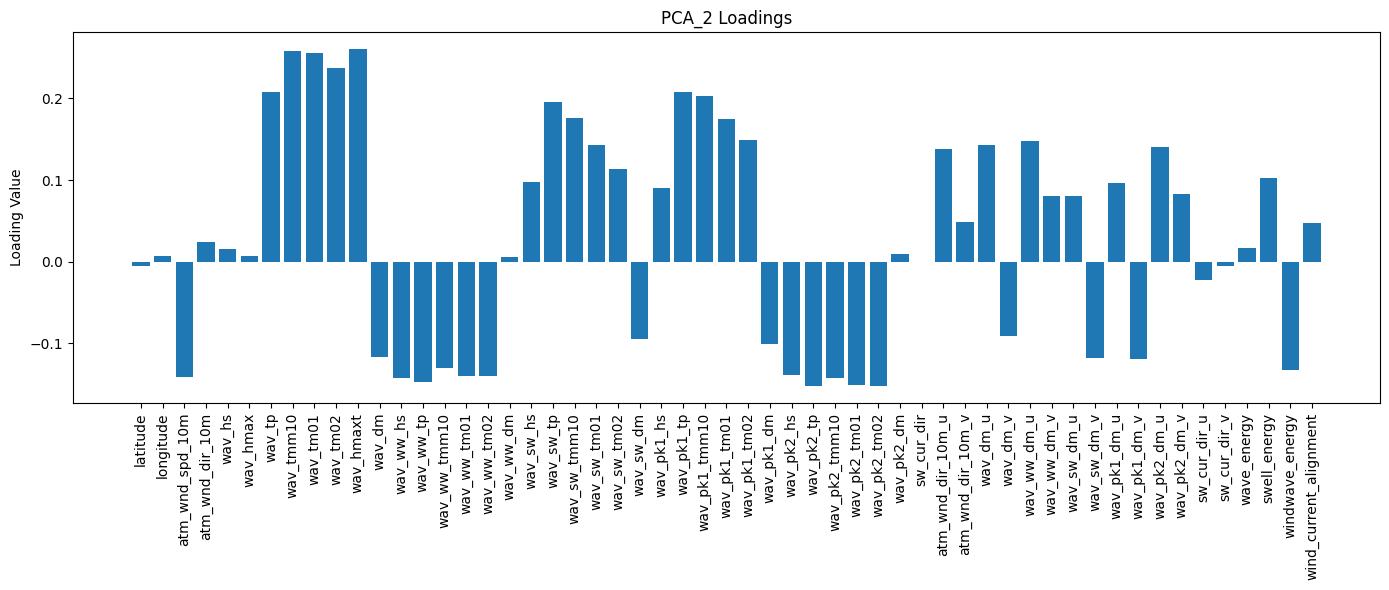

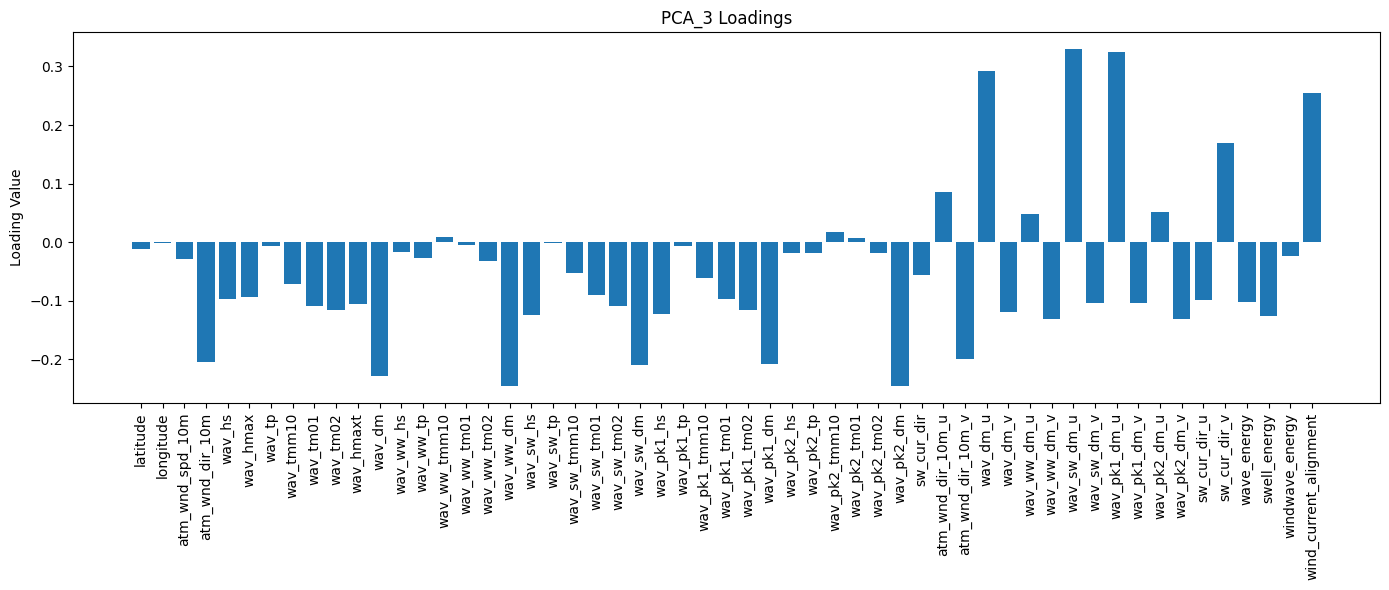

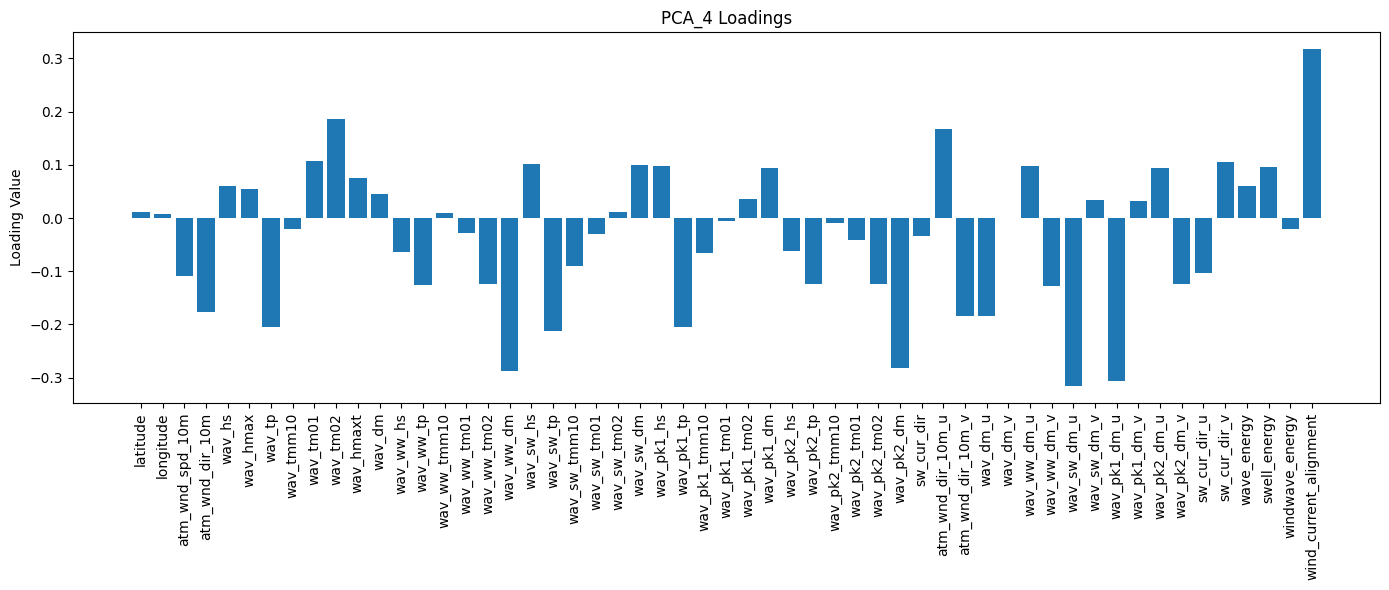

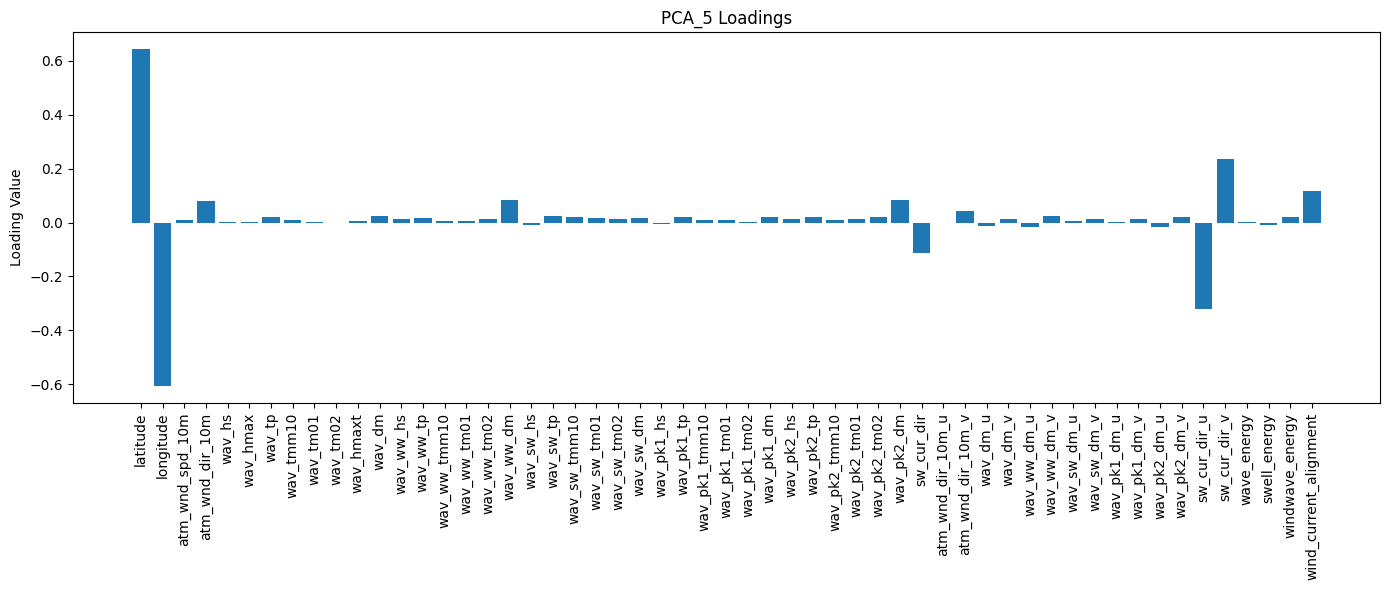

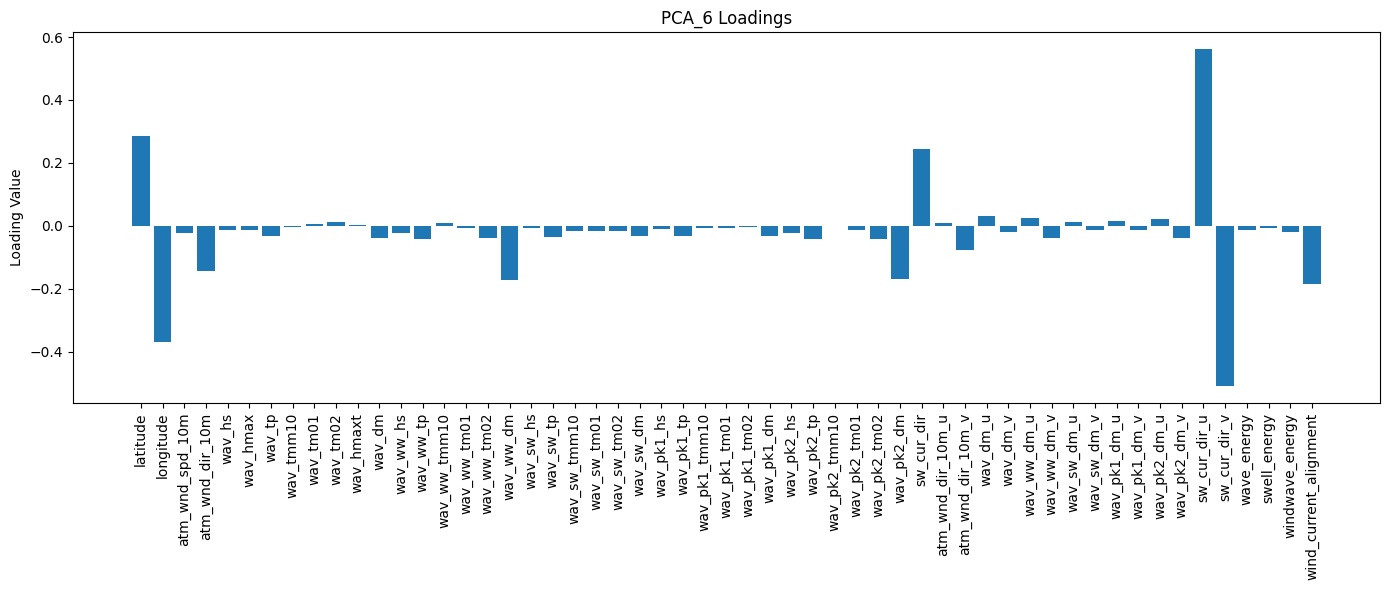

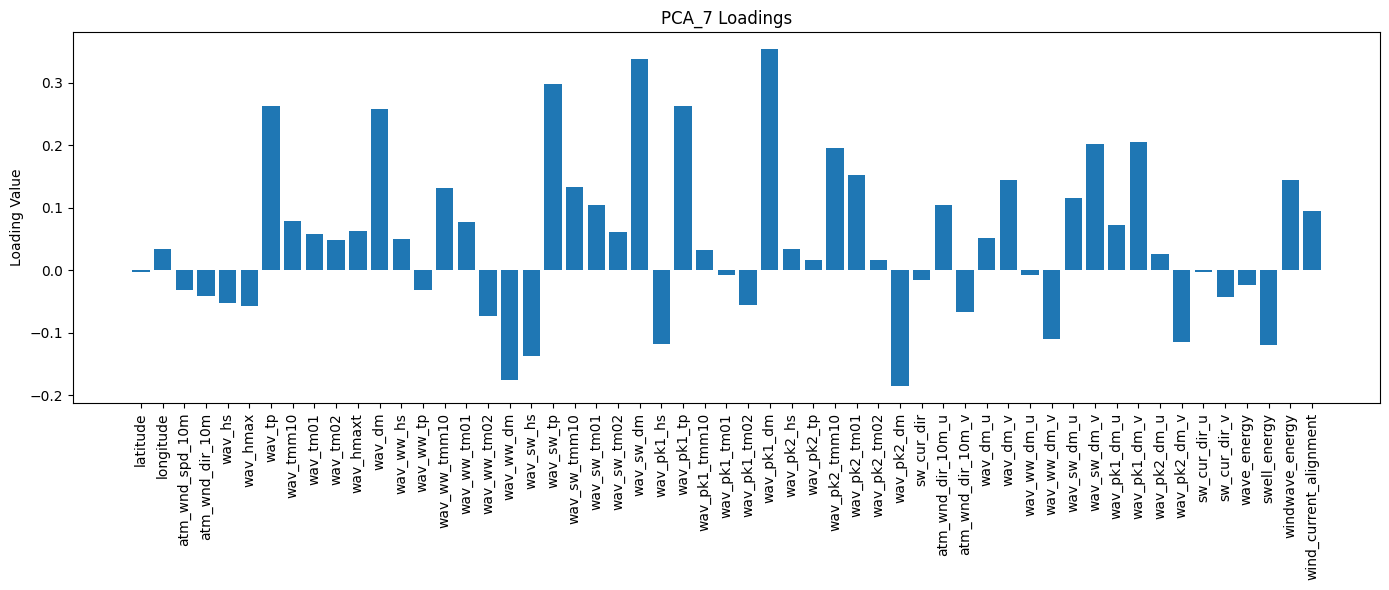

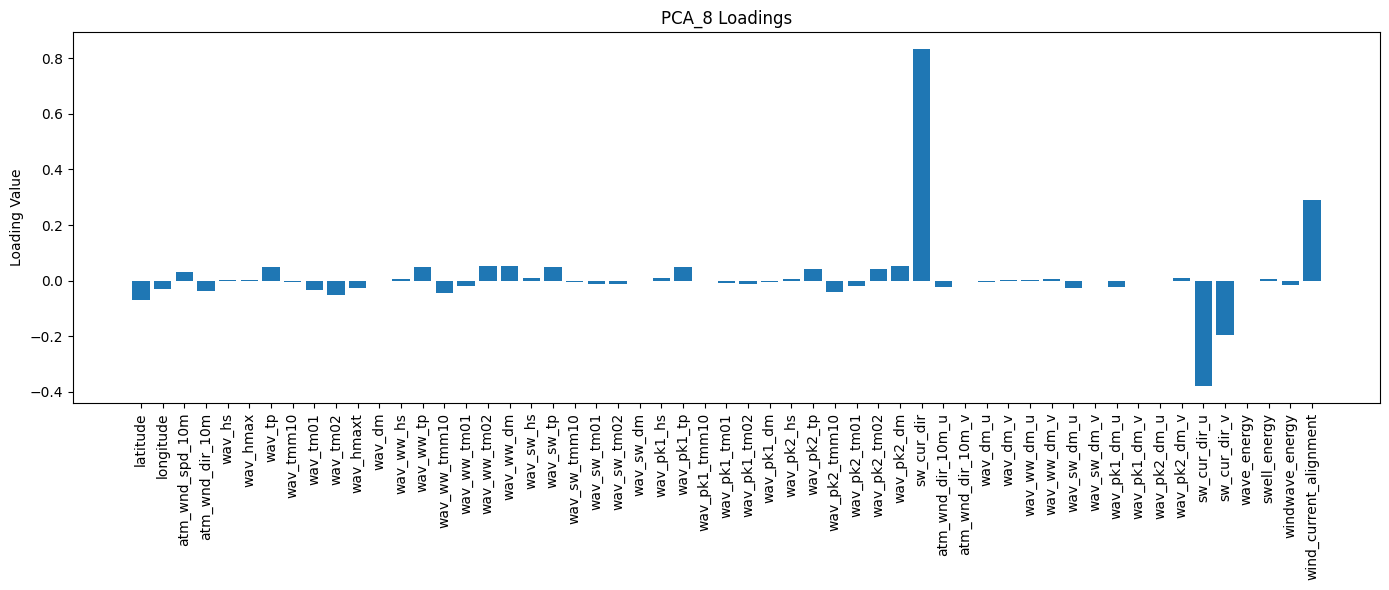

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Build loadings DataFrame (if not yet done)
loading_df = pd.DataFrame(
    pca.components_.T,
    index=features_for_pca,
    columns=[f"PCA_{i+1}" for i in range(pca.n_components_)]
)

# Select how many components to plot
# Example: first 3 components
components_to_plot = ["PCA_1", "PCA_2", "PCA_3", "PCA_4", "PCA_5", "PCA_6", "PCA_7", "PCA_8"]

for comp in components_to_plot:
    values = loading_df[comp].values
    labels = loading_df.index

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(values)), values)
    plt.xticks(range(len(values)), labels, rotation=90)
    plt.ylabel("Loading Value")
    plt.title(f"{comp} Loadings")
    plt.tight_layout()
    plt.show()


In [17]:
print(df.columns.tolist())

['time', 'latitude', 'longitude', 'plat_id', 'atm_wnd_spd_10m', 'atm_wnd_dir_10m', 'wav_hs', 'wav_hmax', 'wav_tp', 'wav_tmm10', 'wav_tm01', 'wav_tm02', 'wav_hmaxt', 'wav_dm', 'wav_ww_hs', 'wav_ww_tp', 'wav_ww_tmm10', 'wav_ww_tm01', 'wav_ww_tm02', 'wav_ww_dm', 'wav_sw_hs', 'wav_sw_tp', 'wav_sw_tmm10', 'wav_sw_tm01', 'wav_sw_tm02', 'wav_sw_dm', 'wav_pk1_hs', 'wav_pk1_tp', 'wav_pk1_tmm10', 'wav_pk1_tm01', 'wav_pk1_tm02', 'wav_pk1_dm', 'wav_pk2_hs', 'wav_pk2_tp', 'wav_pk2_tmm10', 'wav_pk2_tm01', 'wav_pk2_tm02', 'wav_pk2_dm', 'sw_cur_spd', 'sw_cur_dir', 'atm_wnd_dir_10m_u', 'atm_wnd_dir_10m_v', 'wav_dm_u', 'wav_dm_v', 'wav_ww_dm_u', 'wav_ww_dm_v', 'wav_sw_dm_u', 'wav_sw_dm_v', 'wav_pk1_dm_u', 'wav_pk1_dm_v', 'wav_pk2_dm_u', 'wav_pk2_dm_v', 'sw_cur_dir_u', 'sw_cur_dir_v', 'wave_energy', 'swell_energy', 'windwave_energy', 'wind_current_alignment', 'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8']


## Adição de Features Sazonais em Dados Meteo-Oceanográficos

A variação sazonal é um dos principais fatores que controlam a dinâmica
atmosférica e oceânica. Em aplicações de previsão de correntes, ondas e
vento, incorporar **features sazonais** permite que modelos de machine
learning capturem padrões de longo prazo que não são detectáveis apenas
pelos valores instantâneos das variáveis.

In [18]:
def add_seasonal_features(df):
    df['time'] = pd.to_datetime(df['time'])

    df['month'] = df['time'].dt.month
    df['day_of_year'] = df['time'].dt.dayofyear
    
    # Cyclical encodings
    df['annual_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['annual_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

    # Normalized phase
    df['annual_phase'] = df['day_of_year'] / 365.0
    
    # One-hot months (optional, can be many features)
    df = pd.get_dummies(df, columns=['month'], prefix='month')
    
    # Binary seasons
    df['is_summer'] = df['time'].dt.month.isin([12, 1, 2]).astype(int)
    df['is_autumn'] = df['time'].dt.month.isin([3, 4, 5]).astype(int)
    df['is_winter'] = df['time'].dt.month.isin([6, 7, 8]).astype(int)
    df['is_spring'] = df['time'].dt.month.isin([9, 10, 11]).astype(int)

    return df

In [19]:
df = add_seasonal_features(df)

# Compute Pearson correlation
corr = df.corr(numeric_only=True)


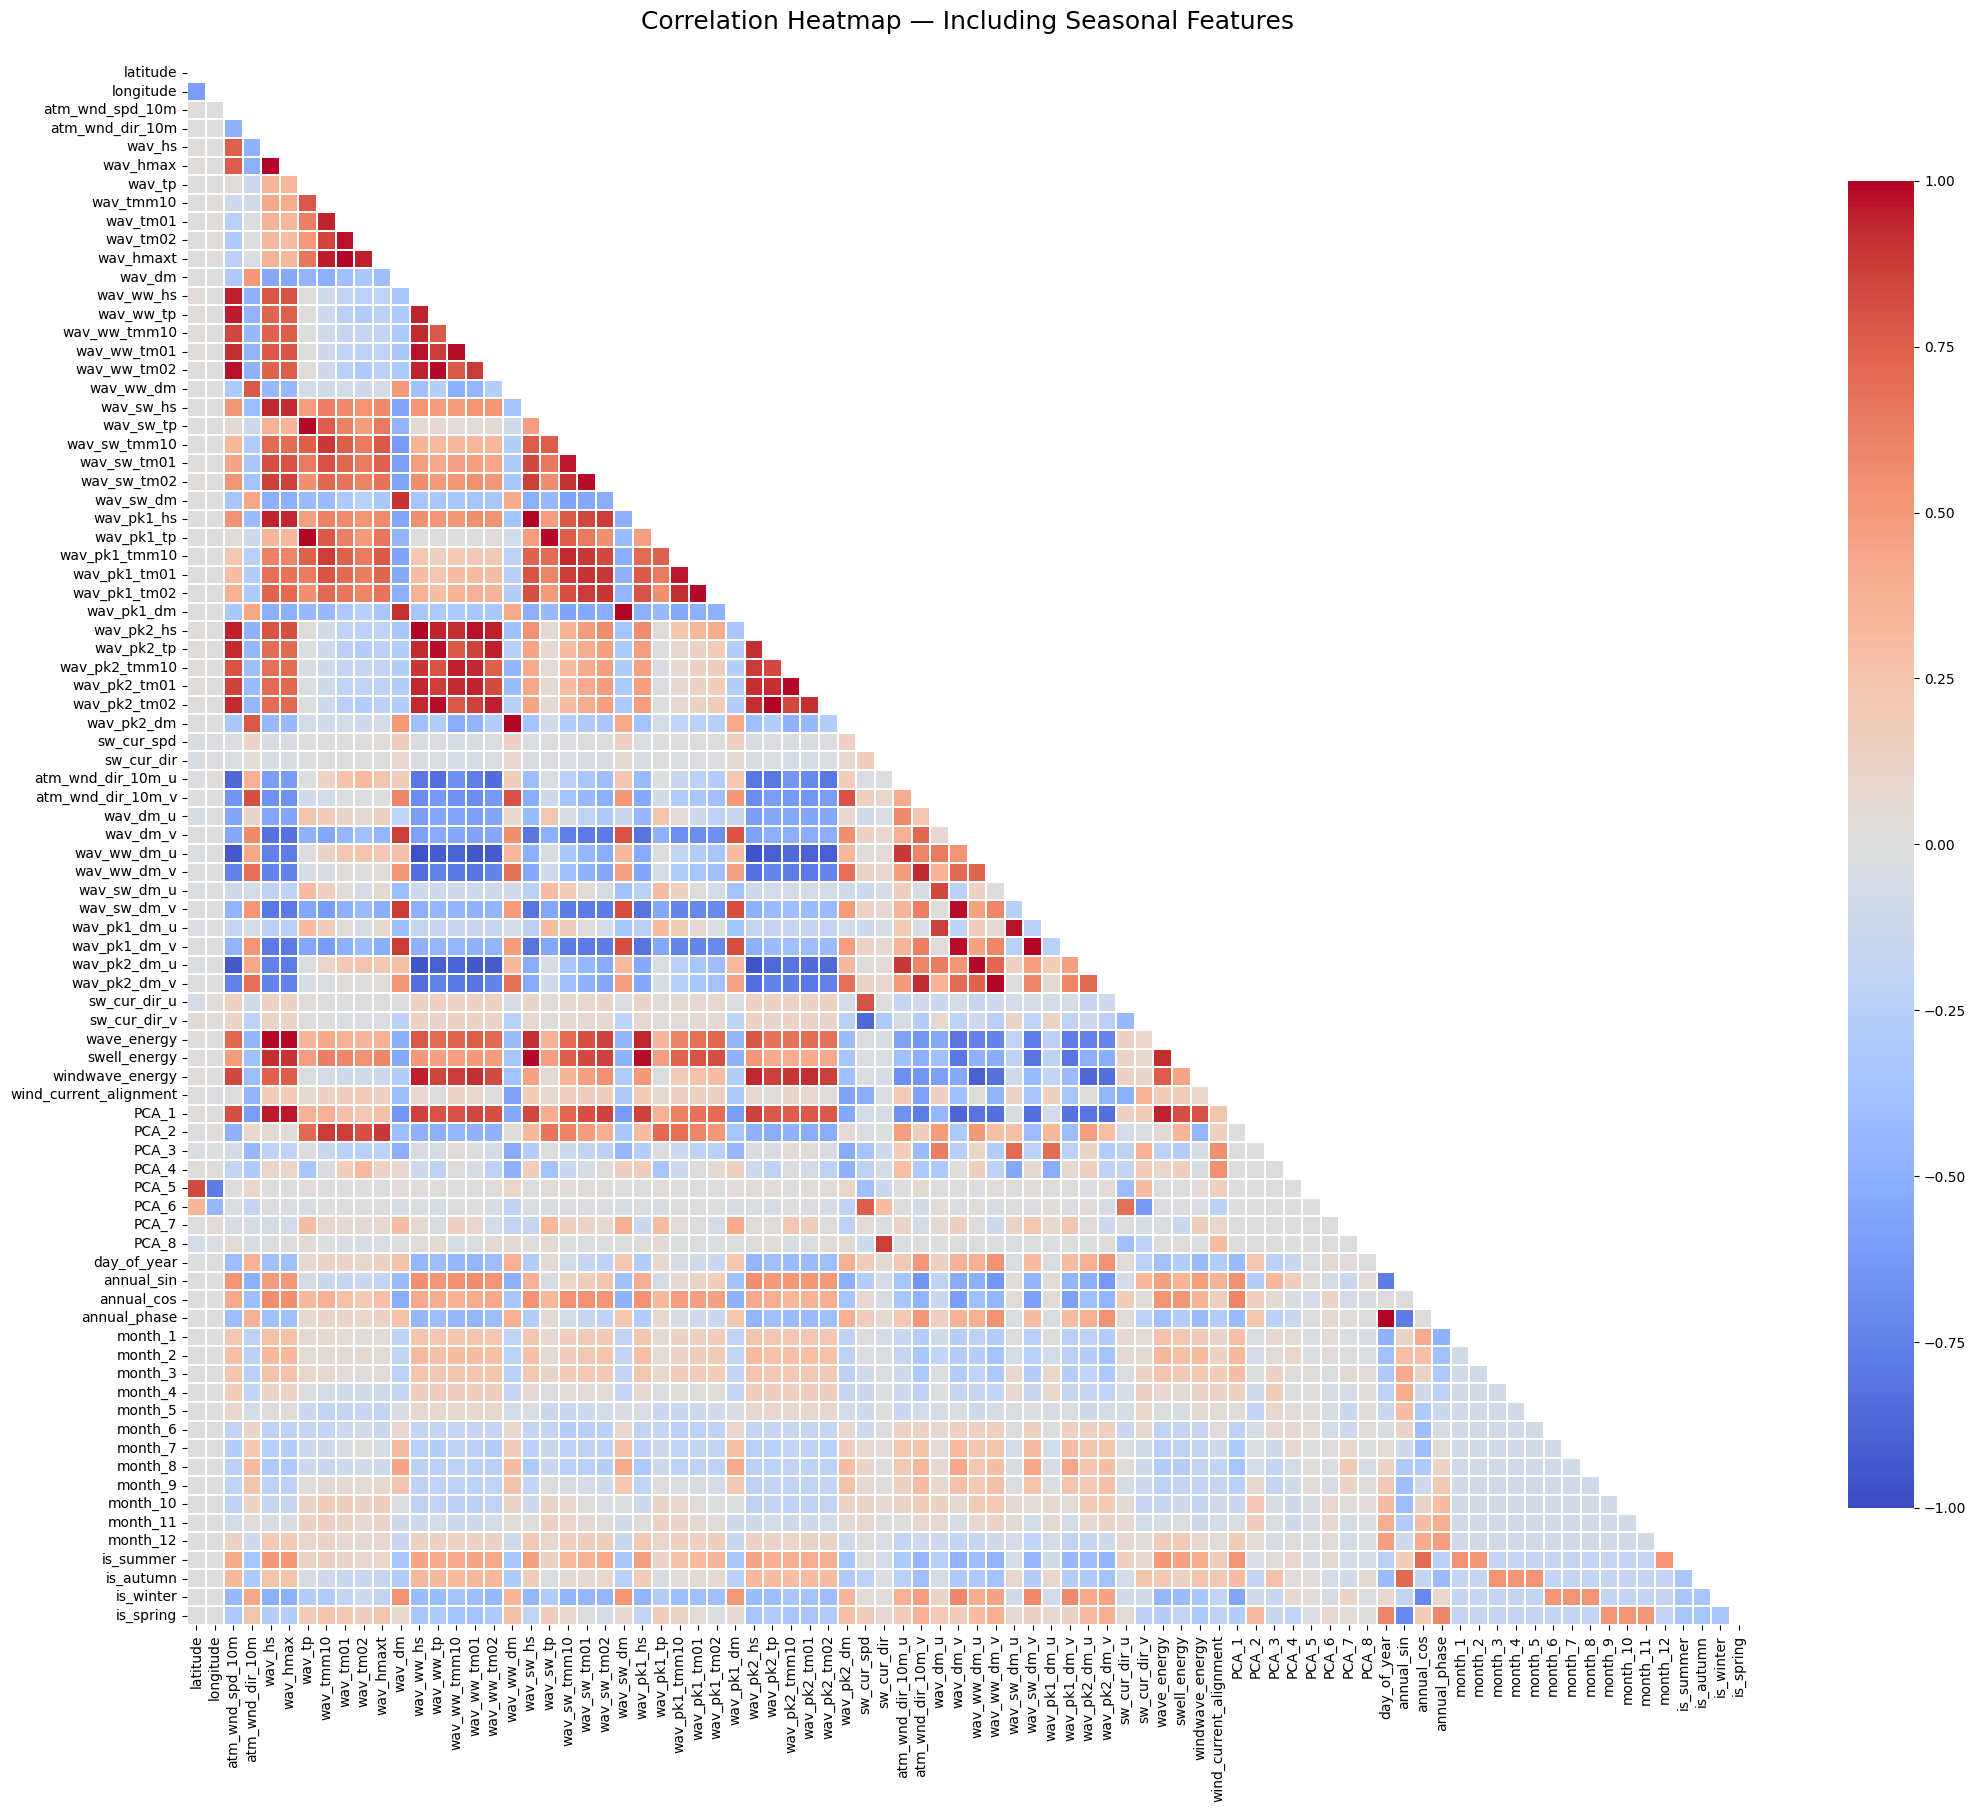

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Fix figure resolution
plt.figure(figsize=(22, 18))

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    vmax=1, vmin=-1,
    center=0,
    square=True,
    linewidths=.3,
    cbar_kws={"shrink": 0.85},
    annot=False  # set True for numbers, but gets messy with many variables
)

plt.title("Correlation Heatmap — Including Seasonal Features", fontsize=18, pad=25)
plt.tight_layout()
plt.show()


directions for currents

In [21]:
import numpy as np

def classify_regime(direction_deg):
    """
    Classifies an input direction (in degrees) into a current regime.
    
    NOTE: We use the *oceanographic convention*: the direction indicates
    where the flow COMES FROM, not where it goes to.
    
    The four regimes are:
      - NBC  : Northwestward flow (coming from ~SE)
      - SEC  : Westward flow (coming from ~E)
      - NECC : Eastward countercurrent (coming from ~W)
      - EUC  : Subsurface eastward current; we reuse the same directional band
    
    Anything that does not fall in these angular windows is labeled "Other".
    """

    # Normalize angle into the interval [0, 360)
    d = direction_deg % 360

    # NBC window: flow coming from 300–330° (i.e., moving SE → NW)
    if 300 <= d <= 330:
        return "NBC"

    # SEC window: flow coming from 250–290° (i.e., moving E → W)
    if 250 <= d <= 290:
        return "SEC"

    # NECC window: flow coming from 70–110° (i.e., moving W → E)
    if 70 <= d <= 110:
        return "NECC"

    # EUC window: subsurface eastward current; uses narrower 80–100°
    if 80 <= d <= 100:
        return "EUC"

    # If angle doesn't match any dominant regime
    return "Other"


def add_directional_regimes(df):
    """
    Adds categorical features indicating which current regime each 
    wind/wave/current direction belongs to.
    
    1. First normalize all direction columns to [0, 360)
    2. Apply classify_regime() to each direction
    3. One-hot encode the resulting categories for ML models
    """

    # Normalize directional angles for wind, wave, and surface current
    df['wind_dir']    = df['atm_wnd_dir_10m'] % 360
    df['wave_dir']    = df['wav_dm'] % 360
    df['current_dir'] = df['sw_cur_dir'] % 360
    
    # Apply regime classification to each directional variable
    df['wind_regime']    = df['wind_dir'].apply(classify_regime)
    df['wave_regime']    = df['wave_dir'].apply(classify_regime)
    df['current_regime'] = df['current_dir'].apply(classify_regime)

    # Convert categorical regimes into one-hot encoding for ML models
    df = pd.get_dummies(df, columns=['wind_regime', 'wave_regime', 'current_regime'])

    return df



# Representative mean headings (direction COMING FROM) for each current regime.
# These are used to compute alignment scores and soft memberships.
REGIME_HEADINGS = {
    "NBC": 315,  # NWward flow, coming from SE
    "SEC": 270,  # Westward flow, coming from East
    "NECC": 90,  # Eastward flow, coming from West
    "EUC": 90,   # EUC also eastward; same directional axis
}

def alignment_score(direction_deg, regime_heading):
    """
    Computes a directional alignment score between:
      - observed direction
      - ideal 'heading' of a regime
    
    The result is cos(angle difference):
        +1 → perfectly aligned
         0 → perpendicular
        -1 → exactly opposite

    This is useful as a *continuous feature* that captures graded similarity,
    not just binary membership.
    """

    # Compute wrapped angle difference in radians
    ang_diff = np.deg2rad((direction_deg - regime_heading) % 360)

    # Cosine of difference gives a directional similarity measure
    return np.cos(ang_diff)



def add_alignment_features(df):
    """
    Adds continuous directional-alignment features for wind, wave, and current.
    
    For each feature and for each regime, we compute:
       alignment = cos(direction - regime_heading)
    
    Produces columns like:
      wind_align_NBC
      wave_align_SEC
      current_align_NECC
    """

    # Loop over directional variables
    for feature, dircol in [
        ('wind', 'wind_dir'),
        ('wave', 'wave_dir'),
        ('current', 'current_dir')
    ]:
        # Loop over each regime prototype heading
        for regime, heading in REGIME_HEADINGS.items():
            df[f'{feature}_align_{regime}'] = df[dircol].apply(
                lambda x: alignment_score(x, heading)
            )
    return df



def soft_membership(direction, mean_deg, kappa=3.0):
    """
    Computes a soft probability-like membership using a von Mises kernel.
    
    This is similar to a 'circular Gaussian':

        exp(kappa * cos(diff))

    - diff : circular difference between direction and regime mean
    - kappa: concentration parameter (higher = narrower peak)
    
    This generates smooth, differentiable, continuous membership values,
    useful for ML models that benefit from graded rather than hard bins.
    """

    diff = np.deg2rad((direction - mean_deg) % 360)
    return np.exp(kappa * np.cos(diff))




def add_soft_membership(df):
    """
    Adds soft membership scores for each direction relative to each regime.
    
    Produces columns like:
      wind_prob_NBC
      wave_prob_SEC
      current_prob_EUC

    These features give the model a probability-like indication of how
    compatible each directional variable is with each current regime.
    """

    for feature, dircol in [
        ('wind', 'wind_dir'),
        ('wave', 'wave_dir'),
        ('current', 'current_dir')
    ]:
        for regime, heading in REGIME_HEADINGS.items():
            df[f'{feature}_prob_{regime}'] = df[dircol].apply(
                lambda x: soft_membership(x, heading)
            )
    return df



def add_directional_features(df):
    """
    Master function that adds:
       1. Regime classification (discrete)
       2. Alignment scores (continuous, cosine-based)
       3. Soft membership (probabilistic / kernel-based)
    
    This becomes a complete feature engineering block for directional variables.
    """

    df = add_directional_regimes(df)
    df = add_alignment_features(df)
    df = add_soft_membership(df)
    return df




In [22]:
df = add_directional_features(df)


Correlation with sw_cur_spd (Spearman):
sw_cur_dir_v             -0.872
wind_current_alignment   -0.481
PCA_5                    -0.385
PCA_3                    -0.342
annual_sin               -0.285
                          ...  
is_spring                 0.193
current_prob_NBC          0.227
current_align_NBC         0.227
PCA_6                     0.749
sw_cur_dir_u              0.799
Name: sw_cur_spd, Length: 98, dtype: float64


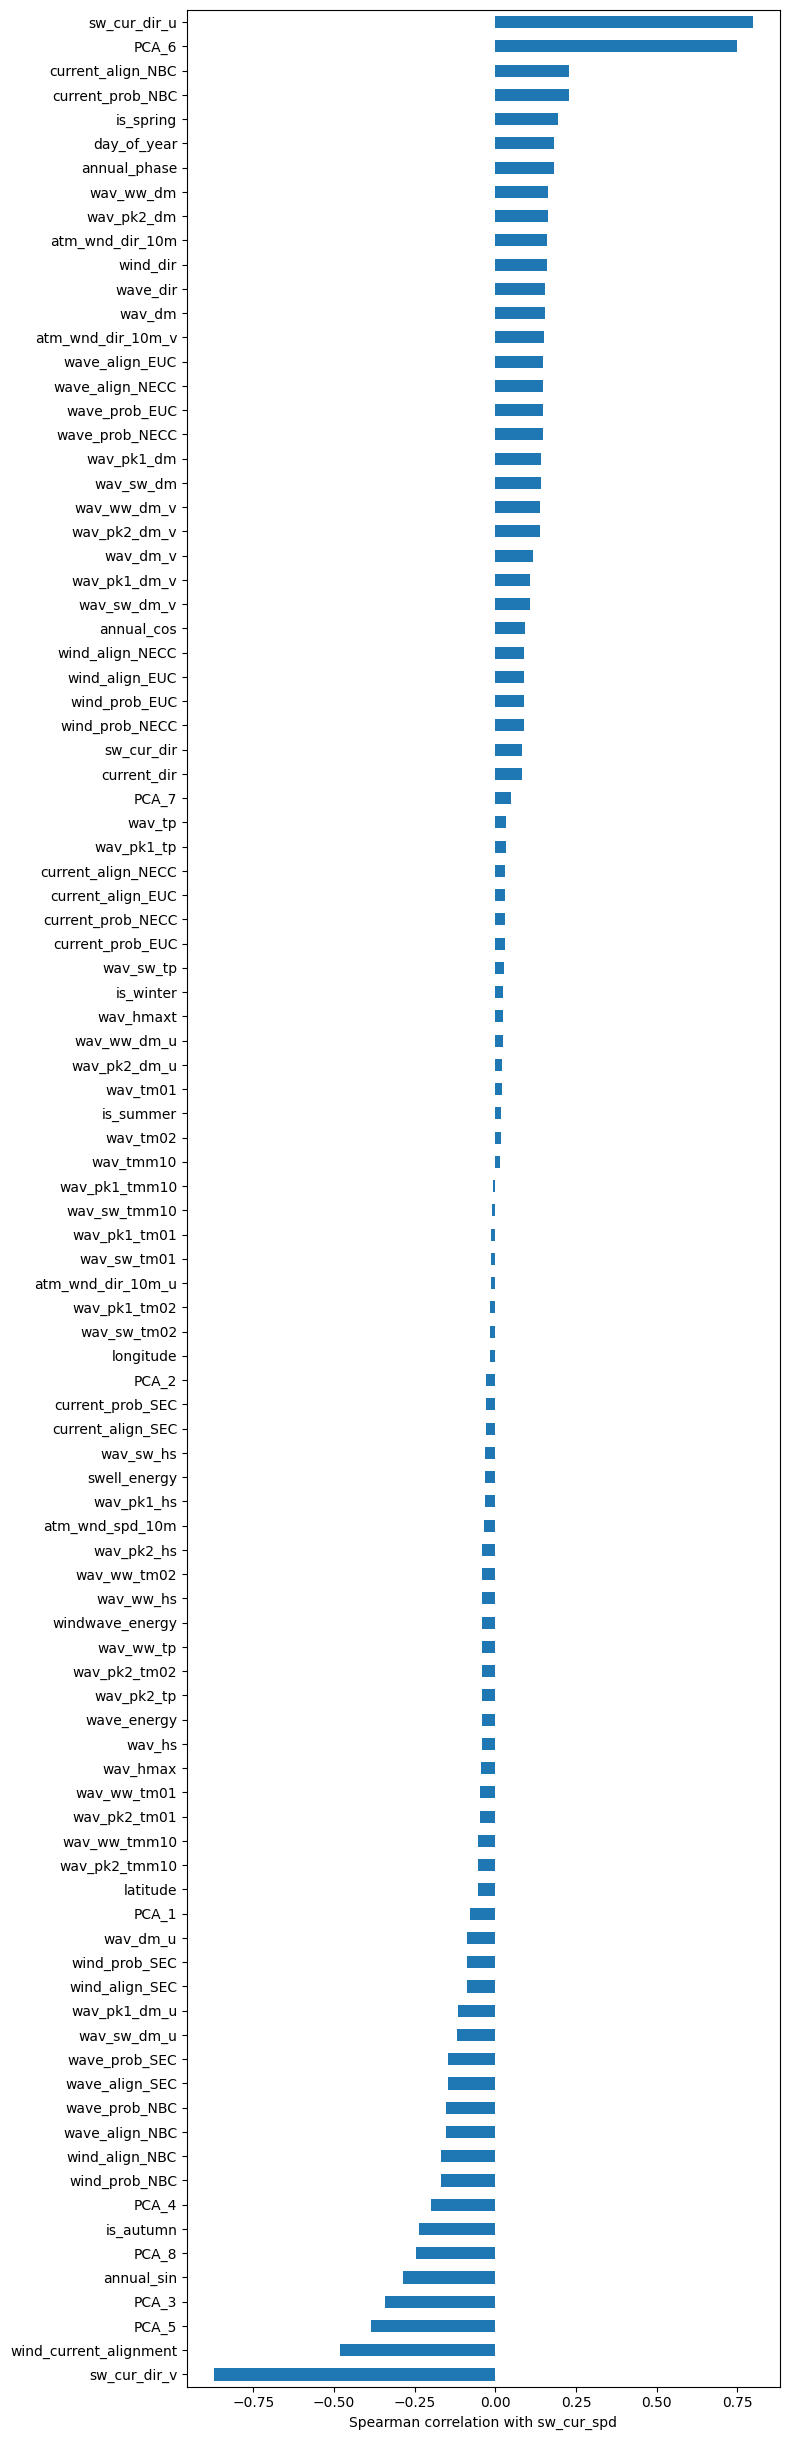

In [23]:
 
import numpy as np
import matplotlib.pyplot as plt

# Ensure numeric columns and that target exists
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if "sw_cur_spd" not in numeric_cols:
    raise KeyError("sw_cur_spd not found in df numeric columns")

# Remove target from list and compute correlations with the target only
numeric_cols.remove("sw_cur_spd")
# Choose method: 'spearman' or 'pearson'
corr_with_sw = df[numeric_cols + ["sw_cur_spd"]].corr(method="spearman", numeric_only=True)["sw_cur_spd"].drop("sw_cur_spd")
corr_with_sw = corr_with_sw.sort_values(ascending=True)  # for horizontal bar plot

# Print and plot
print("Correlation with sw_cur_spd (Spearman):")
print(corr_with_sw.round(3))

plt.figure(figsize=(8, max(4, 0.25 * len(corr_with_sw))))
corr_with_sw.plot.barh(color="C0")
plt.xlabel("Spearman correlation with sw_cur_spd")
plt.tight_layout()
plt.show()
 

# Serie de fourrier

In [24]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

def add_fourier_feature_train_test(
    df,
    value_col,
    time_col='time',
    test_year=2024,
    period_days=365.25,
    n_harmonics=32,
    include_trend=True
):
    """
    Fits Fourier series on data BEFORE test_year
    Writes predictions to df[value_col + '_fourier']
    Evaluates ONLY on test_year
    """

    # --- Ensure datetime ---
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce')

    # --- Train / test split ---
    train_mask = df[time_col].dt.year < test_year
    test_mask  = df[time_col].dt.year == test_year

    if train_mask.sum() < 10:
        raise ValueError("Not enough training data before test year.")
    if test_mask.sum() == 0:
        raise ValueError("No data found for test year.")

    # --- Time reference: first TRAIN timestamp ---
    t0 = df.loc[train_mask, time_col].iloc[0]

    def to_days(t):
        return (t - t0).dt.total_seconds() / 86400.0

    # --- Design matrix ---
    def design_matrix(t_array):
        cols = [np.ones(len(t_array))]
        if include_trend:
            cols.append(t_array)
        for k in range(1, n_harmonics + 1):
            omega = 2.0 * np.pi * k / period_days
            cols.append(np.sin(omega * t_array))
            cols.append(np.cos(omega * t_array))
        return np.vstack(cols).T

    # --- Fit (TRAIN ONLY) ---
    t_train = to_days(df.loc[train_mask, time_col]).values
    y_train = df.loc[train_mask, value_col].values

    A_train = design_matrix(t_train)
    coeffs, *_ = np.linalg.lstsq(A_train, y_train, rcond=None)

    # --- Predict (FULL DF, NO LEAKAGE IN FIT) ---
    df[f'{value_col}_fourier'] = np.nan

    t_all = to_days(df[time_col])
    valid = t_all.notna()

    A_all = design_matrix(t_all[valid].values)
    df.loc[valid, f'{value_col}_fourier'] = A_all @ coeffs

    # --- Evaluation ONLY on test year ---
    eval_mask = (
        test_mask &
        df[value_col].notna() &
        df[f'{value_col}_fourier'].notna()
    )

    mse = mean_squared_error(
        df.loc[eval_mask, value_col],
        df.loc[eval_mask, f'{value_col}_fourier']
    )

    return mse

mse_2024 = add_fourier_feature_train_test(
    df,
    value_col='sw_cur_spd',
    time_col='time',
    test_year=2024,
    n_harmonics=32,
    include_trend=True
)

print("Test MSE (2024):", mse_2024)

df[['time', 'sw_cur_spd', 'sw_cur_spd_fourier']].head()


Test MSE (2024): 0.1610490371412013


,time,sw_cur_spd,sw_cur_spd_fourier
0,2015-01-01 00:00:00,1.41974,1.184939
1,2015-01-01 01:00:00,1.41897,1.185039
2,2015-01-01 02:00:00,1.41820,1.185127
3,2015-01-01 03:00:00,1.41743,1.185203
4,2015-01-01 04:00:00,1.41666,1.185268


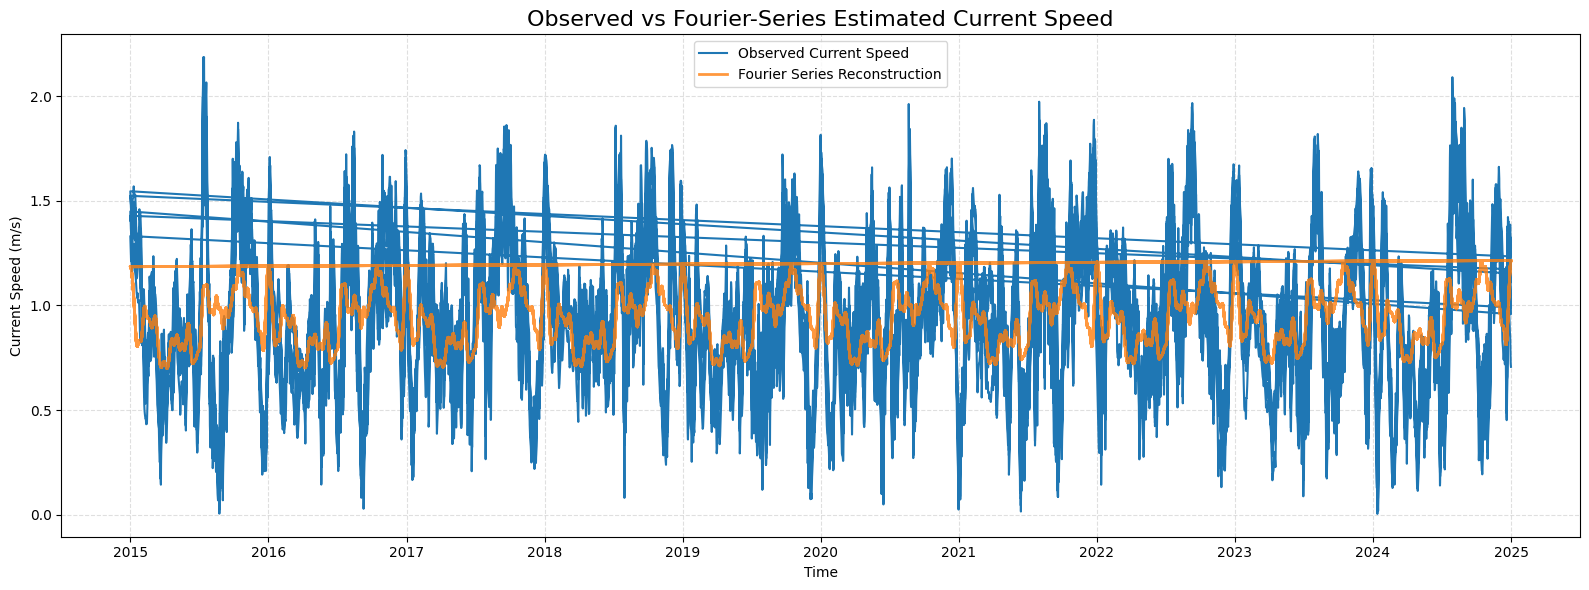

In [25]:
import matplotlib.pyplot as plt

# Select a time window if the dataset is large
# (Optional: comment this out if you want the full series)
df_plot = df.copy()
# df_plot = df_plot.iloc[:2000]   # example: first 2000 hours

plt.figure(figsize=(16, 6))

plt.plot(
    df_plot['time'],
    df_plot['sw_cur_spd'],
    label='Observed Current Speed',
    linewidth=1.5
)

plt.plot(
    df_plot['time'],
    df_plot['sw_cur_spd_fourier'],
    label='Fourier Series Reconstruction',
    linewidth=2,
    alpha=0.8
)

plt.title("Observed vs Fourier-Series Estimated Current Speed", fontsize=16)
plt.xlabel("Time")
plt.ylabel("Current Speed (m/s)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


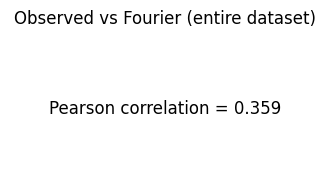

In [26]:
import matplotlib.pyplot as plt

corr = df['sw_cur_spd'].corr(df['sw_cur_spd_fourier'])

plt.figure(figsize=(4, 2))
plt.text(
    0.5, 0.5,
    f"Pearson correlation = {corr:.3f}",
    ha='center', va='center', fontsize=12
)
plt.axis('off')
plt.title("Observed vs Fourier (entire dataset)")
plt.show()


Correlation with sw_cur_spd (Spearman):
sw_cur_dir_v             -0.872
wind_current_alignment   -0.481
PCA_5                    -0.385
PCA_3                    -0.342
annual_sin               -0.285
                          ...  
current_prob_NBC          0.227
current_align_NBC         0.227
sw_cur_spd_fourier        0.378
PCA_6                     0.749
sw_cur_dir_u              0.799
Name: sw_cur_spd, Length: 99, dtype: float64


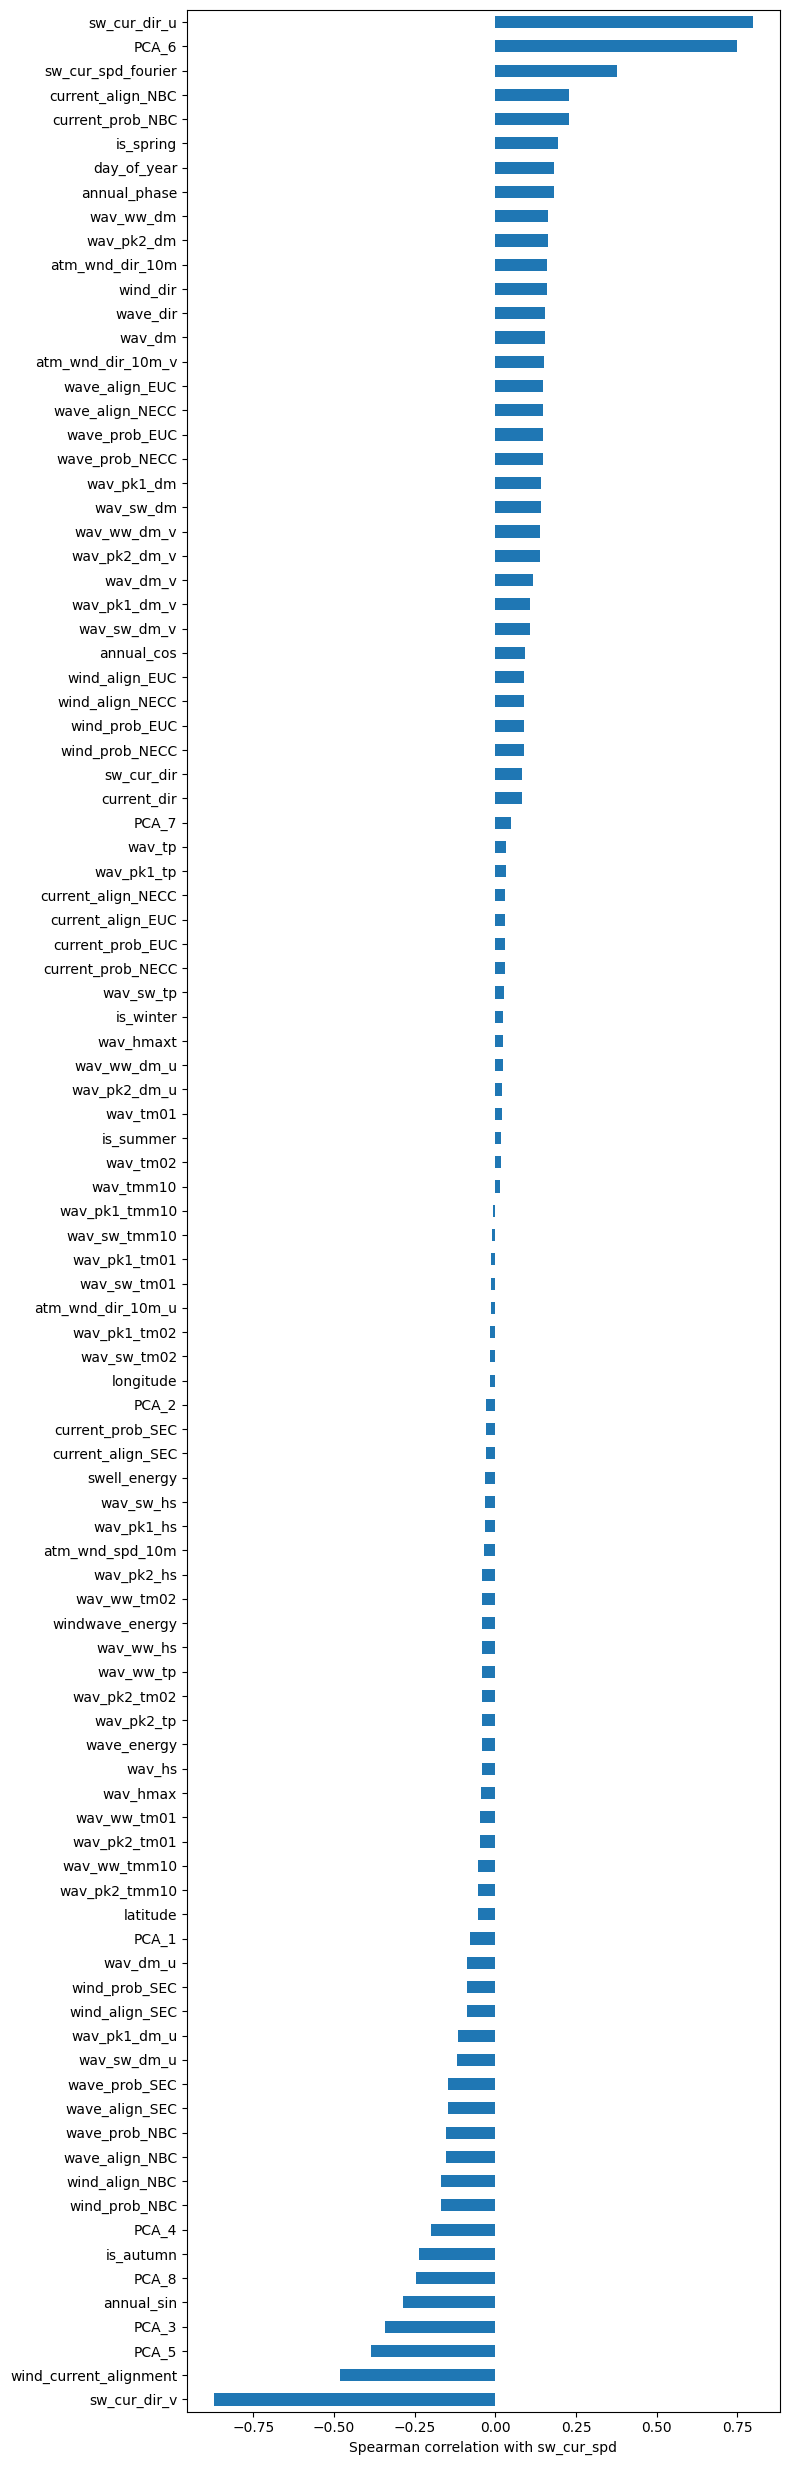

In [27]:
 
import numpy as np
import matplotlib.pyplot as plt

# Ensure numeric columns and that target exists
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if "sw_cur_spd" not in numeric_cols:
    raise KeyError("sw_cur_spd not found in df numeric columns")

# Remove target from list and compute correlations with the target only
numeric_cols.remove("sw_cur_spd")
# Choose method: 'spearman' or 'pearson'
corr_with_sw = df[numeric_cols + ["sw_cur_spd"]].corr(method="spearman", numeric_only=True)["sw_cur_spd"].drop("sw_cur_spd")
corr_with_sw = corr_with_sw.sort_values(ascending=True)  # for horizontal bar plot

# Print and plot
print("Correlation with sw_cur_spd (Spearman):")
print(corr_with_sw.round(3))

plt.figure(figsize=(8, max(4, 0.25 * len(corr_with_sw))))
corr_with_sw.plot.barh(color="C0")
plt.xlabel("Spearman correlation with sw_cur_spd")
plt.tight_layout()
plt.show()
 

In [28]:
# print all column names
print(df.columns.tolist())


['time', 'latitude', 'longitude', 'plat_id', 'atm_wnd_spd_10m', 'atm_wnd_dir_10m', 'wav_hs', 'wav_hmax', 'wav_tp', 'wav_tmm10', 'wav_tm01', 'wav_tm02', 'wav_hmaxt', 'wav_dm', 'wav_ww_hs', 'wav_ww_tp', 'wav_ww_tmm10', 'wav_ww_tm01', 'wav_ww_tm02', 'wav_ww_dm', 'wav_sw_hs', 'wav_sw_tp', 'wav_sw_tmm10', 'wav_sw_tm01', 'wav_sw_tm02', 'wav_sw_dm', 'wav_pk1_hs', 'wav_pk1_tp', 'wav_pk1_tmm10', 'wav_pk1_tm01', 'wav_pk1_tm02', 'wav_pk1_dm', 'wav_pk2_hs', 'wav_pk2_tp', 'wav_pk2_tmm10', 'wav_pk2_tm01', 'wav_pk2_tm02', 'wav_pk2_dm', 'sw_cur_spd', 'sw_cur_dir', 'atm_wnd_dir_10m_u', 'atm_wnd_dir_10m_v', 'wav_dm_u', 'wav_dm_v', 'wav_ww_dm_u', 'wav_ww_dm_v', 'wav_sw_dm_u', 'wav_sw_dm_v', 'wav_pk1_dm_u', 'wav_pk1_dm_v', 'wav_pk2_dm_u', 'wav_pk2_dm_v', 'sw_cur_dir_u', 'sw_cur_dir_v', 'wave_energy', 'swell_energy', 'windwave_energy', 'wind_current_alignment', 'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8', 'day_of_year', 'annual_sin', 'annual_cos', 'annual_phase', 'month_1', 'mont

In [29]:
# save to new CSV
output_path = 'dados_csv/processed_metocean_current_data.csv'
df.to_csv(output_path, index=False)
print(f"✅ Processed data saved to {output_path}")

✅ Processed data saved to dados_csv/processed_metocean_current_data.csv


In [30]:
# print ammount of columns and each row seperatly
print(f"Total columns: {len(df.columns)}")
for col in df.columns:
    print(col)

Total columns: 124
time
latitude
longitude
plat_id
atm_wnd_spd_10m
atm_wnd_dir_10m
wav_hs
wav_hmax
wav_tp
wav_tmm10
wav_tm01
wav_tm02
wav_hmaxt
wav_dm
wav_ww_hs
wav_ww_tp
wav_ww_tmm10
wav_ww_tm01
wav_ww_tm02
wav_ww_dm
wav_sw_hs
wav_sw_tp
wav_sw_tmm10
wav_sw_tm01
wav_sw_tm02
wav_sw_dm
wav_pk1_hs
wav_pk1_tp
wav_pk1_tmm10
wav_pk1_tm01
wav_pk1_tm02
wav_pk1_dm
wav_pk2_hs
wav_pk2_tp
wav_pk2_tmm10
wav_pk2_tm01
wav_pk2_tm02
wav_pk2_dm
sw_cur_spd
sw_cur_dir
atm_wnd_dir_10m_u
atm_wnd_dir_10m_v
wav_dm_u
wav_dm_v
wav_ww_dm_u
wav_ww_dm_v
wav_sw_dm_u
wav_sw_dm_v
wav_pk1_dm_u
wav_pk1_dm_v
wav_pk2_dm_u
wav_pk2_dm_v
sw_cur_dir_u
sw_cur_dir_v
wave_energy
swell_energy
windwave_energy
wind_current_alignment
PCA_1
PCA_2
PCA_3
PCA_4
PCA_5
PCA_6
PCA_7
PCA_8
day_of_year
annual_sin
annual_cos
annual_phase
month_1
month_2
month_3
month_4
month_5
month_6
month_7
month_8
month_9
month_10
month_11
month_12
is_summer
is_autumn
is_winter
is_spring
wind_dir
wave_dir
current_dir
wind_regime_NBC
wind_regime_NECC
wind_r

In [31]:
sssss

NameError: name 'sssss' is not defined

In [ ]:
target = "sw_cur_spd"

physics_features = [
    "wave_energy", "swell_energy", "windwave_energy",
    "wind_current_alignment",
    "atm_wnd_spd_10m",
    "atm_wnd_dir_10m_u", "atm_wnd_dir_10m_v",
    "sw_cur_dir_u", "sw_cur_dir_v",
]

pca_features = [col for col in df.columns if col.startswith("PCA_")]

X = df[physics_features + pca_features]
y = df[target]


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


: 

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from math import sqrt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Parameters
lookback = 24   # timesteps to use for prediction (adjust)
test_frac = 0.2
batch_size = 32
epochs = 100
random_seed = 42
tf.random.set_seed(random_seed)
np.random.seed(random_seed)

# Prepare arrays
X_vals = X.values.astype(float)
y_vals = y.values.reshape(-1, 1).astype(float)

# Scale features and target
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_vals)
y_scaled = scaler_y.fit_transform(y_vals)

# Build sequences
def create_sequences(Xs, ys, lookback):
    Xs_seq, ys_seq = [], []
    for i in range(lookback, len(Xs)):
        Xs_seq.append(Xs[i-lookback:i])
        ys_seq.append(ys[i])
    return np.array(Xs_seq), np.array(ys_seq)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, lookback)
n_samples, timesteps, n_features = X_seq.shape

# Train/test split (preserve order)
split_idx = int((1 - test_frac) * n_samples)
X_train_seq, X_test_seq = X_seq[:split_idx], X_seq[split_idx:]
y_train_seq, y_test_seq = y_seq[:split_idx], y_seq[split_idx:]

# Build LSTM
model = Sequential([
    LSTM(64, input_shape=(timesteps, n_features), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mse'])
model.summary()

# Train
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[es],
    verbose=2
)

# Predict and evaluate (inverse scale)
y_pred_scaled = model.predict(X_test_seq)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test_seq)

rmse = sqrt(mean_squared_error(y_true, y_pred))
print(f'LSTM test RMSE: {rmse:.4f}')
 

2025-11-27 13:04:46.598157: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-27 13:04:46.634651: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-27 13:04:47.965012: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
ssssss

In [ ]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
)

model.fit(X_train, y_train)

In [ ]:
import shap
import xgboost as xgb

booster = model.get_booster()
booster.set_param({"predictor": "cpu_predictor"})  # required for SHAP stability

config = booster.save_config()

# Fix base_score format
config = config.replace('"[', '"').replace(']"', '"')

booster.load_config(config)

import shap
explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_train)



/home/eduardo/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


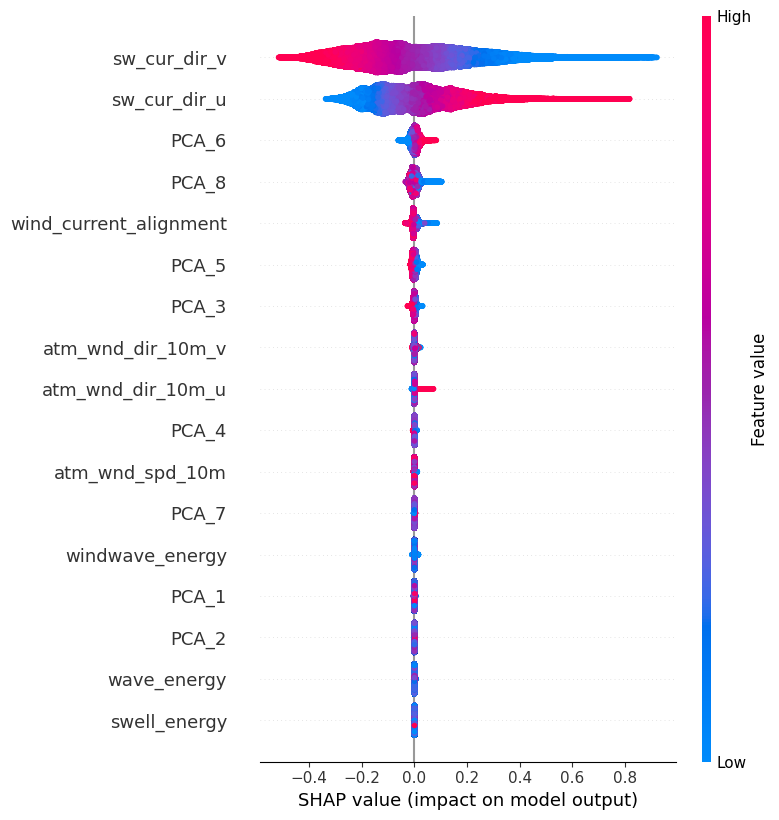

In [ ]:
shap.summary_plot(shap_values, X_train)